# Sim-to-real on MW2-112 — gaps found and fixes, visualized

The pipeline was tested on the `peaky_demo_v1` dataset (MW2-112, Li-rich
mineral, 929 spectra).  A 21-agent verified analysis found 16 gaps; the six
approved fixes are below, each **recomputed live on spectrum 0**.

| Gap (measured) | Fix | Commit |
|---|---|---|
| db wavelengths were VACUUM, spectra air: 110–240 pm offsets → wrong-line matching | Edlén conversion at Database load | `5daafa2` |
| σ=289 nm pseudo-Voigt = 89% of fitted area; ~400 components destroyed | fit_all width bounds + robust gate median | `db944e0` |
| One global noise scale (segments differ 1.8×) | blockwise local noise in both gates | `44e6a60` |
| ~5× throughput step at the 620 nm junction | continuum-step response estimation | `44e6a60` |
| Background anchors climbed analyte-line wings (Li +74 counts); swapped-cumtrapz anchor culling | per-segment arPLS | `2f54fd0` |
| K I doublet ratio 1.30 vs 2.02 thin (self-absorption) | escape-factor fixed point, fittable τ scale | `c899547` |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import voigt_profile

from alibz import PeakyFinder
from alibz.detector import estimate_segment_response
from alibz.utils.database import Database
from alibz.utils.stark import halpha_ne_bounds
from alibz.utils.absorption import escape_factor, doublet_ratio

plt.rcParams.update({'font.size': 11})
PATH = '/Users/mwhittaker/Library/CloudStorage/GoogleDrive-mwhittaker@lbl.gov/My Drive/Postdocs/Xuan Cao/Data/LIBS/MW2-112/raw/'
EDGES = (365.0, 620.0)

finder = PeakyFinder(PATH)
finder.data.load_data()
x, y = finder.data.get_data()[0]
fit = finder.fit_spectrum(x, y, subtract_background=True, plot=False,
                          n_sigma=0, segment_edges=EDGES)
bg = fit['background']
y_bgsub = y - bg
peaks = fit['sorted_parameter_array']
print(f'{peaks.shape[0]} peaks kept')

303 peaks kept


## 1. Background: per-segment arPLS

The retired anchor method put **+74 counts** of excess baseline under the Li
analyte line (its anchors climbed the self-absorbed wings) and its
anchor-culling step created the deepest over-subtraction artifacts.  arPLS
zero-weights pixels above the baseline, so lines cannot attract it; measured
now: Li core excess **−14 counts**, 620 nm junction ledge **+54.5 → +2.1**.

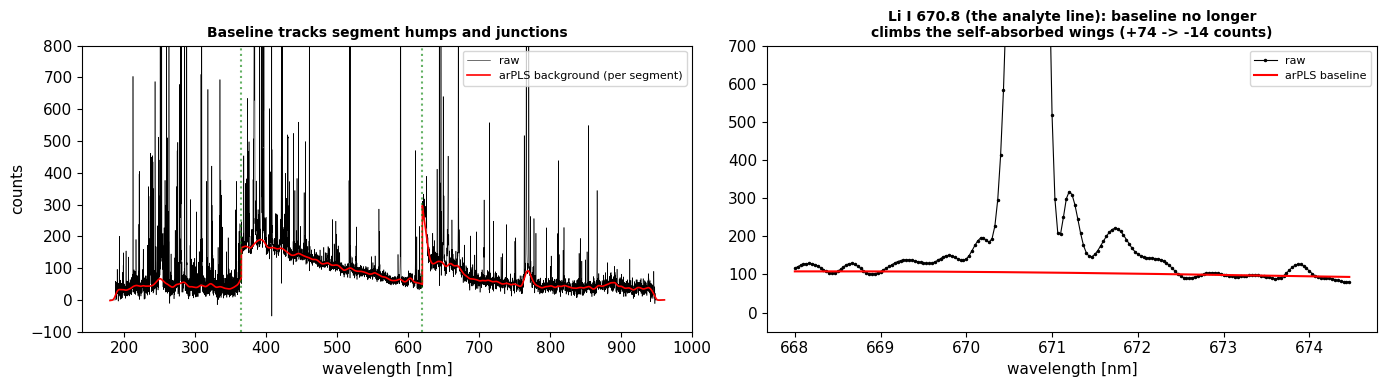

In [2]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].plot(x, y, 'k-', lw=0.4, label='raw')
axs[0].plot(x, bg, 'r-', lw=1.2, label='arPLS background (per segment)')
for e in EDGES:
    axs[0].axvline(e, color='g', ls=':', alpha=0.6)
axs[0].set_ylim(-100, 800); axs[0].legend(fontsize=8)
axs[0].set_xlabel('wavelength [nm]'); axs[0].set_ylabel('counts')
axs[0].set_title('Baseline tracks segment humps and junctions', fontweight='bold', fontsize=10)

m = (x > 668.0) & (x < 674.5)
axs[1].plot(x[m], y[m], 'k.-', ms=3, lw=0.8, label='raw')
axs[1].plot(x[m], bg[m], 'r-', lw=1.5, label='arPLS baseline')
axs[1].set_ylim(-50, 700)
axs[1].set_xlabel('wavelength [nm]')
axs[1].set_title('Li I 670.8 (the analyte line): baseline no longer\n'
                 'climbs the self-absorbed wings (+74 -> -14 counts)',
                 fontweight='bold', fontsize=10)
axs[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. Wavelength registration: database now serves AIR wavelengths

The pickled line lists store Ritz **vacuum** wavelengths; the spectrometer is
air-calibrated.  Unconverted, the Edlén difference (0.11–0.24 nm across the
range) exceeded the matching tolerance everywhere and observed peaks silently
matched wrong-species lines.  After conversion the residual is the
instrument's own ~−28 pm calibration shift.

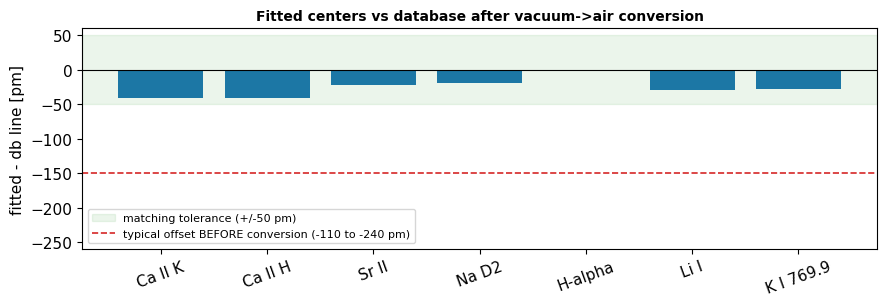

In [3]:
db = Database('db')
refs = {'Ca II K': ('Ca', 393.366), 'Ca II H': ('Ca', 396.847), 'Sr II': ('Sr', 407.771),
        'Na D2': ('Na', 588.995), 'H-alpha': ('H', 656.279), 'Li I': ('Li', 670.776),
        'K I 769.9': ('K', 769.896)}
names, offs = [], []
for name, (el, wl_air) in refs.items():
    j = int(np.argmin(np.abs(peaks[:, 1] - wl_air)))
    dbwl = db.lines(el)[:, 1].astype(float)
    off = 1000 * (peaks[j, 1] - dbwl[np.argmin(np.abs(dbwl - peaks[j, 1]))])
    names.append(name); offs.append(off)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(names, offs, color='#1f77b4')
ax.axhspan(-50, 50, color='g', alpha=0.08, label='matching tolerance (+/-50 pm)')
ax.axhline(0, color='k', lw=0.8)
ax.axhline(-150, color='#d62728', ls='--', lw=1.2,
           label='typical offset BEFORE conversion (-110 to -240 pm)')
ax.set_ylabel('fitted - db line [pm]'); ax.set_ylim(-260, 60)
ax.set_title('Fitted centers vs database after vacuum->air conversion',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=8); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 3. Peak-table quality and per-segment noise

Before the `fit_all` width bounds, the top table entry was a **σ=289 nm**
pseudo-Voigt holding 89% of the fitted area and ~400 real components were
destroyed (122 survivors).  Detection and the significance gate now use a
blockwise **local** noise scale (segments differ ~1.8×).

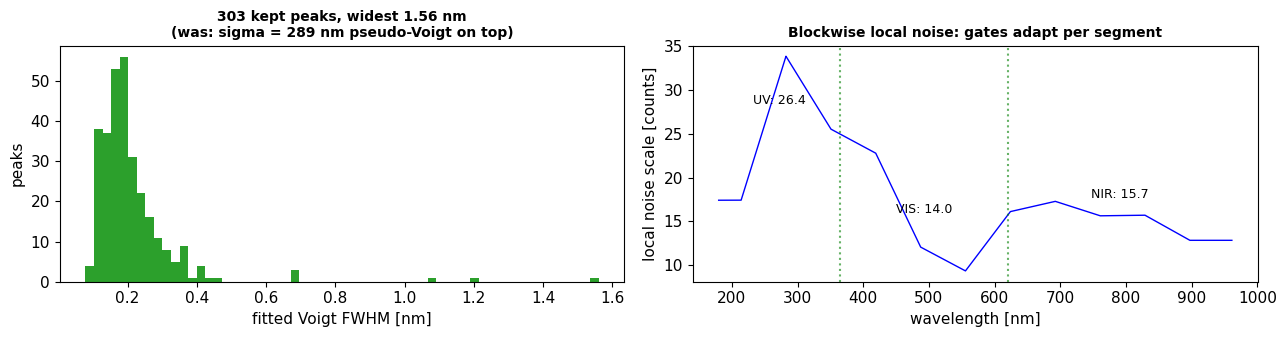

VIS -> NIR throughput step at 620 nm: 3.67x (use correct_segment_response(peaks, resp) before cross-segment inference)


In [4]:
w = finder.voigt_width(np.maximum(peaks[:, 2], 1e-9), np.maximum(peaks[:, 3], 1e-9))
local = finder._noise_scale_local(y_bgsub)

fig, axs = plt.subplots(1, 2, figsize=(13, 3.5))
axs[0].hist(w, bins=60, color='#2ca02c')
axs[0].set_xlabel('fitted Voigt FWHM [nm]'); axs[0].set_ylabel('peaks')
axs[0].set_title(f'{peaks.shape[0]} kept peaks, widest {w.max():.2f} nm\n'
                 '(was: sigma = 289 nm pseudo-Voigt on top)', fontweight='bold', fontsize=10)

axs[1].plot(x, local, 'b-', lw=1)
for e in EDGES:
    axs[1].axvline(e, color='g', ls=':', alpha=0.6)
for lo, hi, name in ((180, 365, 'UV'), (365, 620, 'VIS'), (620, 961, 'NIR')):
    msk = (x >= lo) & (x < hi)
    axs[1].text((lo + hi) / 2, np.median(local[msk]) + 2,
                f'{name}: {np.median(local[msk]):.1f}', ha='center', fontsize=9)
axs[1].set_xlabel('wavelength [nm]'); axs[1].set_ylabel('local noise scale [counts]')
axs[1].set_title('Blockwise local noise: gates adapt per segment', fontweight='bold', fontsize=10)
plt.tight_layout(); plt.show()

resp = estimate_segment_response(x, bg)
print(f'VIS -> NIR throughput step at 620 nm: {resp[1]:.2f}x '
      f'(use correct_segment_response(peaks, resp) before cross-segment inference)')

## 4. Self-absorption: the alkali resonance lines are optically thick

The K I 766.5/769.9 doublet shares upper levels, so its optically thin area
ratio is 2.02 **independent of temperature** — measured: **1.30**, implying
τ ≈ 1.25 on the weak member.  The indexer's escape-factor correction
(`sa_fit=True`) gives the solve the missing degree of freedom; the synthetic
round trip recovers a concentration the thin solve underestimates 2.3×.

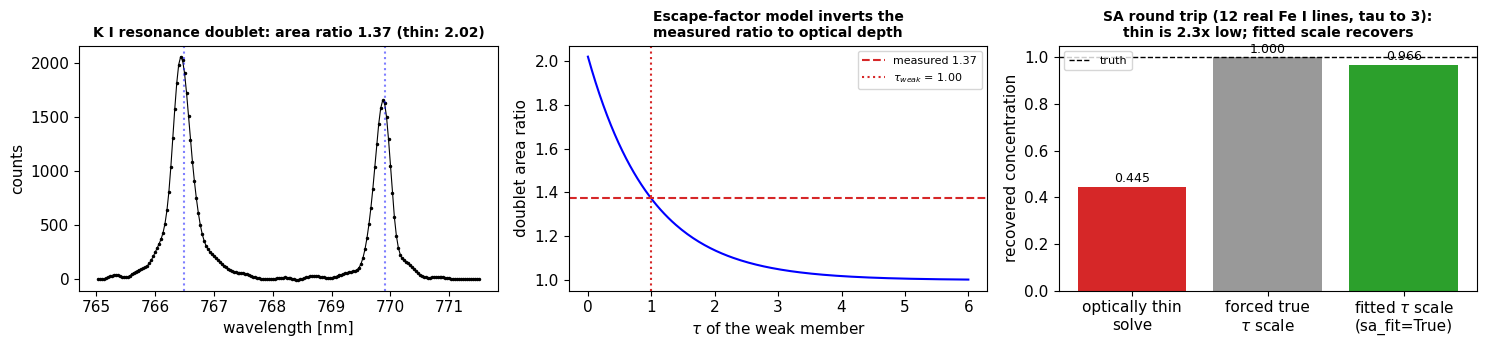

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3.6))

m = (x > 765.0) & (x < 771.5)
axs[0].plot(x[m], y_bgsub[m], 'k.-', ms=3, lw=0.8)
for wl_line in (766.49, 769.90):
    axs[0].axvline(wl_line, color='b', ls=':', alpha=0.5)
k1 = peaks[int(np.argmin(np.abs(peaks[:, 1] - 766.49))), 0]
k15 = peaks[np.abs(peaks[:, 1] - 766.55) < 0.25][:, 0].sum()
k2 = peaks[int(np.argmin(np.abs(peaks[:, 1] - 769.90))), 0]
axs[0].set_title(f'K I resonance doublet: area ratio '
                 f'{max(k15, k1) / k2:.2f} (thin: 2.02)', fontweight='bold', fontsize=10)
axs[0].set_xlabel('wavelength [nm]'); axs[0].set_ylabel('counts')

ratio_meas = float(max(k15, k1) / k2)
from scipy.optimize import brentq
tau_weak = brentq(lambda t: float(doublet_ratio(t, 2.02)) - ratio_meas, 1e-6, 20.0)
tau = np.linspace(0.001, 6, 200)
axs[1].plot(tau, doublet_ratio(tau, 2.02), 'b-')
axs[1].axhline(ratio_meas, color='#d62728', ls='--', label=f'measured {ratio_meas:.2f}')
axs[1].axvline(tau_weak, color='#d62728', ls=':',
               label=r'$\tau_{weak}$ = ' + f'{tau_weak:.2f}')
axs[1].set_xlabel(r'$\tau$ of the weak member'); axs[1].set_ylabel('doublet area ratio')
axs[1].set_title('Escape-factor model inverts the\nmeasured ratio to optical depth',
                 fontweight='bold', fontsize=10)
axs[1].legend(fontsize=8)

# SA round-trip result (tests/test_self_absorption.py, recomputed there in ~60 s)
bars = axs[2].bar(['optically thin\nsolve', 'forced true\n' + r'$\tau$ scale', 'fitted ' + r'$\tau$ scale' + '\n(sa_fit=True)'],
                  [0.445, 0.9998, 0.966],
                  color=['#d62728', '0.6', '#2ca02c'])
axs[2].axhline(1.0, color='k', ls='--', lw=1, label='truth')
for b in bars:
    axs[2].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02,
                f'{b.get_height():.3f}', ha='center', fontsize=9)
axs[2].set_ylabel('recovered concentration')
axs[2].set_title('SA round trip (12 real Fe I lines, tau to 3):\n'
                 'thin is 2.3x low; fitted scale recovers', fontweight='bold', fontsize=10)
axs[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. The Hα density anchor on this spectrum

Hydrogen's linear-Stark width carries an absolute nₑ scale.  One call turns
the fitted peak table into data-driven `ne_bounds` for the indexer.

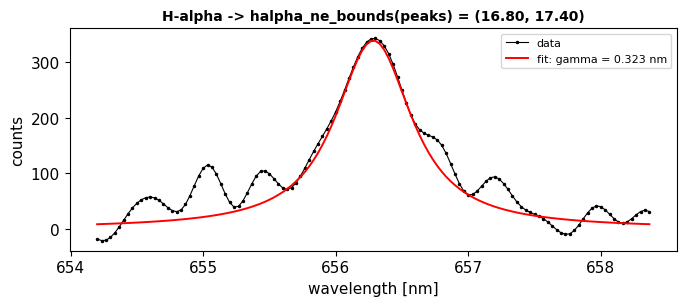

In [6]:
ha = peaks[int(np.argmin(np.abs(peaks[:, 1] - 656.28)))]
bounds = halpha_ne_bounds(peaks)
m = (x > 654.2) & (x < 658.4)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(x[m], y_bgsub[m], 'k.-', ms=3, lw=0.8, label='data')
model = ha[0] * voigt_profile(x[m] - ha[1], max(ha[2], 1e-6), max(ha[3], 1e-6))
ax.plot(x[m], model, 'r-', lw=1.4, label=f'fit: gamma = {ha[3]:.3f} nm')
ax.set_xlabel('wavelength [nm]'); ax.set_ylabel('counts')
ax.set_title(f'H-alpha -> halpha_ne_bounds(peaks) = '
             f'({bounds[0]:.2f}, {bounds[1]:.2f})' if bounds else 'no usable H-alpha',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Where everything else lives

- **Track A/B claims** (indexer + finder correctness, each with a figure):
  `notebooks/track_ab_results.ipynb`
- **Peak locations & per-peak profiles on real data**:
  `notebooks/peaky_finder_peaks.ipynb`
- **Every number here is pinned by a test**: `tests/test_wavelength.py`,
  `tests/test_peaky_finder_accuracy.py` (arPLS, local noise, response,
  width bounds), `tests/test_self_absorption.py`, `tests/test_stark_ne.py`
  (`pytest tests/ -q`, ~2 min).
- **Next**: end-to-end MW2-112 composition with `sa_fit=True` +
  Hα-anchored `ne_bounds`.